# BESS Dispatch Analysis

This notebook runs the BESS (Battery Energy Storage System) strategy over the same period as the virtual trading backtest and analyses dispatch behaviour across eight dimensions:

1. **Price & Dispatch Overlay** — DA price curve vs. MW dispatch decisions for a sample day
2. **SOC Health Distribution** — Heatmap of SOC levels by time-of-day across all backtest days
3. **Rebalancing Impact** — DA-committed schedule vs. final executed dispatch
4. **PnL Waterfall** — Decomposition of net PnL into DA revenue, intraday gains, imbalance costs, and degradation
5. **Performance Summary** — Net PnL, Sharpe, max drawdown, and degradation cost
6. **Revenue Decomposition** — Component-level breakdown table and bar chart
7. **Dispatch Efficiency** — DA-committed vs. actual dispatched MW per period
8. **Degradation vs. Revenue** — Cumulative degradation cost vs. gross revenue by month

The strategy uses LP optimisation (PuLP/HiGHS) for Day-Ahead scheduling and a three-rule intraday engine for real-time adjustments. **The DA schedule uses realised DA prices (oracle scheduling)**, which represents the theoretical upper bound on achievable BESS dispatch revenue for this asset configuration.

In [ ]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.bess.bess_asset import BESSAsset
from src.bess.da_optimizer import optimize_da_schedule
from src.bess.intraday_manager import run_intraday_session
from src.utils.config import load_config

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

ARTIFACT_DIR     = REPO_ROOT / "artifacts" / "da_positioning" / "s4_n10_t50_tc10"
STARTING_CAPITAL = 50_000.0

config   = load_config(REPO_ROOT / "configs" / "config.yaml")
BESS_CFG = config["bess"]

---
## Helpers

Reusable data-loading functions. All paths resolve against `ARTIFACT_DIR` set above.

In [ ]:
def load_features() -> pd.DataFrame:
    """Load the feature/price parquet from the shared artifact."""
    df = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.set_index("time").sort_index()


def load_virtual_signals() -> pd.DataFrame:
    """Load virtual strategy signals CSV from the shared artifact."""
    df = pd.read_csv(
        ARTIFACT_DIR / "virtual" / "trading" / "signals.csv",
        parse_dates=["delivery_time"],
    )
    df["delivery_time"] = pd.to_datetime(df["delivery_time"], utc=True)
    return df


def load_virtual_pnl() -> pd.DataFrame:
    """Load virtual strategy PnL CSV from the shared artifact."""
    df = pd.read_csv(
        ARTIFACT_DIR / "virtual" / "trading" / "pnl.csv",
        parse_dates=["time"],
    )
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df

---
## Data Loading

Load the feature/price dataset and the virtual signals from the shared artifact. The analysis period is pinned to the virtual strategy's walk-forward test window so both strategies are evaluated on identical dates.

In [ ]:
features_df = load_features()

# Derive the analysis period from the virtual signals (walk-forward test window)
_signals = load_virtual_signals()
ANALYSIS_START = _signals["delivery_time"].min()
ANALYSIS_END   = _signals["delivery_time"].max()

# Filter features to the analysis period
features_period = features_df.loc[ANALYSIS_START:ANALYSIS_END]

# Resample to hourly — BESS LP and intraday manager operate at 1-hour resolution
prices = (
    features_period[["day_ahead_price", "mid_price", "system_buy_price"]]
    .resample("1h").mean()
    .dropna()
)

# BESSAsset asset kwargs
_ASSET_FIELDS = {"capacity_mwh", "power_mw", "charge_efficiency",
                 "discharge_efficiency", "degradation_cost_per_mwh", "initial_soc_pct"}
asset_kwargs = {k: v for k, v in BESS_CFG.items() if k in _ASSET_FIELDS}

features_period_london = features_period.copy()
features_period_london.index = features_period_london.index.tz_convert("Europe/London")

print(f"Analysis period : {ANALYSIS_START.date()} → {ANALYSIS_END.date()}")
print(f"Price rows (1h) : {len(prices)}")
print(f"Feature rows    : {len(features_period)}")

---
## BESS Backtest

Run the BESS pipeline day-by-day over the analysis period. The DA schedule is solved by LP against **realised DA prices** (oracle scheduling), providing the upper bound on achievable dispatch revenue. Intraday rules then execute against MID and imbalance prices in the delivery window.

In [15]:
daily_results    = []
all_dispatch_logs = []
all_da_schedules  = []

for date, day_df in prices.groupby(prices.index.date):
    n_hours = len(day_df)
    if n_hours not in {23, 24, 25}:
        continue

    # DA price schedule: use realised prices (oracle upper bound)
    da_prices   = day_df["day_ahead_price"].tolist()
    mid_prices  = day_df["mid_price"].tolist()
    imb_prices  = day_df["system_buy_price"].tolist()

    asset    = BESSAsset(**asset_kwargs)
    schedule = optimize_da_schedule(da_prices, asset)

    asset.reset()
    result = run_intraday_session(
        da_schedule=schedule,
        da_price_actual=da_prices,
        mid_prices=mid_prices,
        imbalance_prices=imb_prices,
        asset=asset,
        config=BESS_CFG,
    )

    daily_results.append({
        "date":             pd.Timestamp(date),
        "da_revenue":       result["da_revenue"],
        "intraday_pnl":     result["intraday_pnl"],
        "imbalance_pnl":    result["imbalance_pnl"],
        "degradation_cost": result["total_degradation_cost"],
        "net_pnl":          result["net_pnl"],
    })

    for entry in result["dispatch_log"]:
        entry["date"] = date
        entry["hour"] = entry["period"]
        entry["timestamp"] = day_df.index[entry["period"]]
    all_dispatch_logs.extend(result["dispatch_log"])

    for h, mw in enumerate(schedule):
        all_da_schedules.append({
            "date":      date,
            "hour":      h,
            "timestamp": day_df.index[h],
            "da_mw":     mw,
        })

results_df  = pd.DataFrame(daily_results)
dispatch_df = pd.DataFrame(all_dispatch_logs)
da_sched_df = pd.DataFrame(all_da_schedules)

print(f"Backtest complete : {len(results_df)} days")
print(f"Total net PnL     : £{results_df['net_pnl'].sum():,.0f}")
print(f"Mean daily PnL    : £{results_df['net_pnl'].mean():,.0f}")

Backtest complete : 144 days
Total net PnL     : £173,837
Mean daily PnL    : £1,207


---
## 1. BESS Strategy Showcase — Price → Dispatch → SOC

Three-panel causal chain for a representative median-spread day: the DA price signal drives the LP dispatch decision, which in turn evolves the battery state of charge. This illustrates the core BESS strategy logic — charge at low prices, discharge at high prices — on a typical (not cherry-picked) trading day.

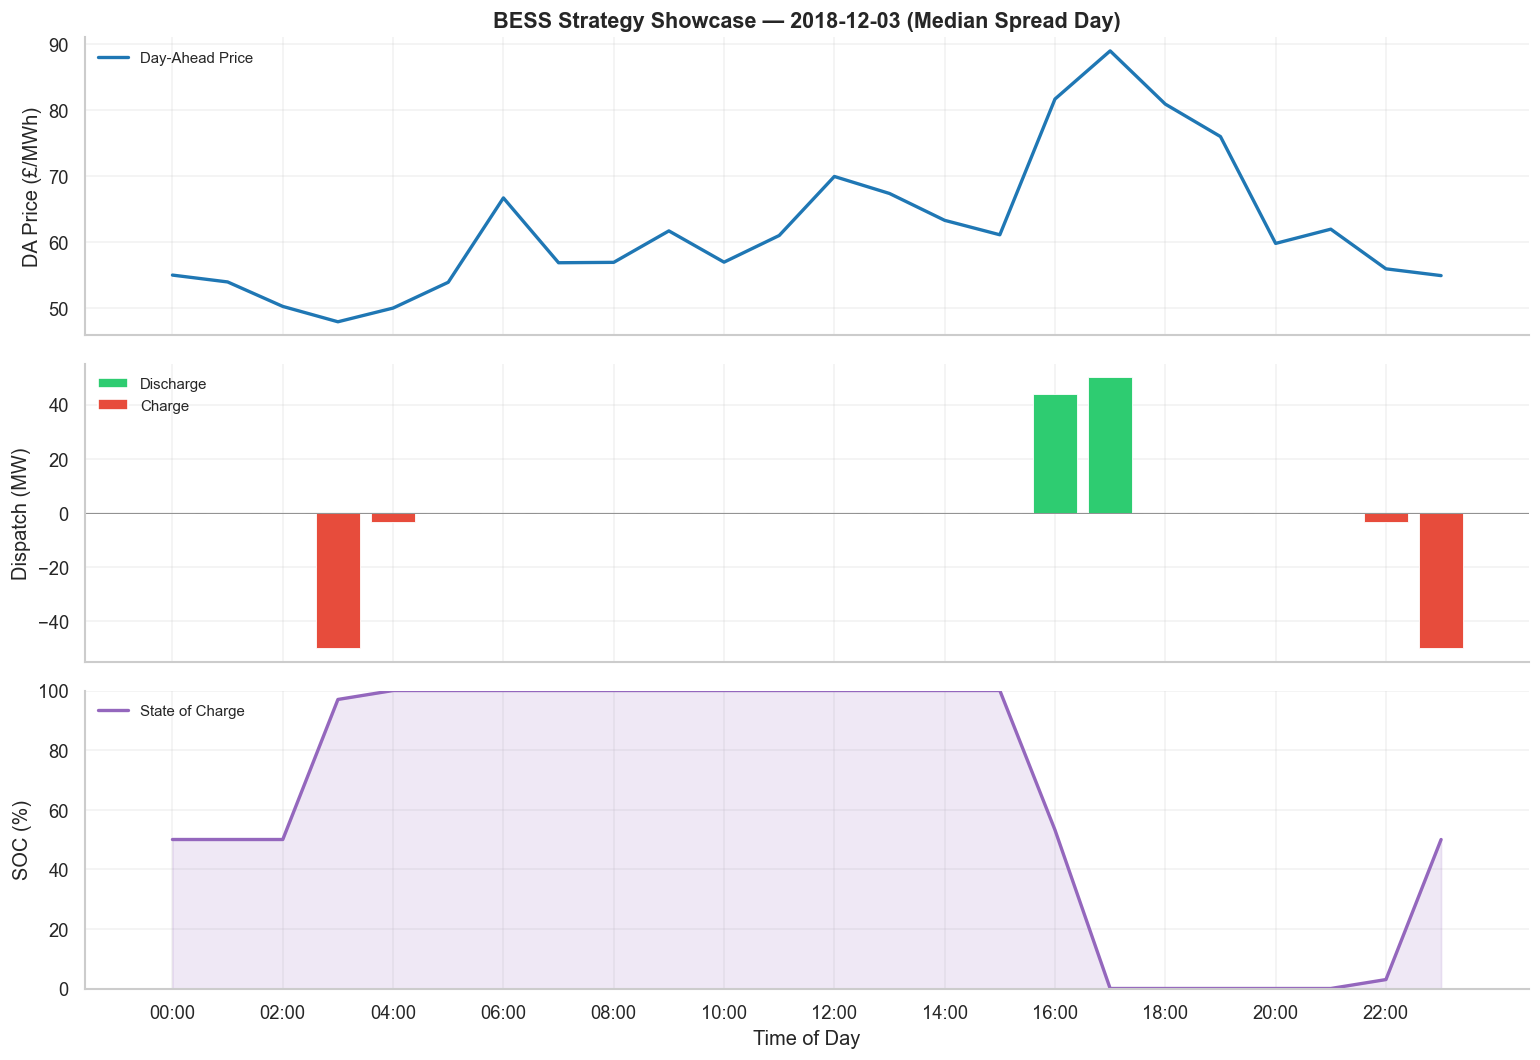

Selected day: 2018-12-03 | DA spread: £41.1/MWh (median: £40.8/MWh)


In [16]:
# Select the day with the median absolute DA spread (representative, not best)
valid_dates = set(da_sched_df["date"].unique())
mask = np.array([d in valid_dates for d in prices.index.date])
valid_prices = prices[mask]
daily_spread = valid_prices.groupby(valid_prices.index.date)["day_ahead_price"].apply(
    lambda x: x.max() - x.min()
)
median_spread = daily_spread.median()
sample_date = daily_spread.iloc[(daily_spread - median_spread).abs().argsort()[:1]].index[0]

# Extract data for the selected day
day_prices = prices.loc[prices.index.date == sample_date]
day_sched = da_sched_df[da_sched_df["date"] == sample_date].sort_values("hour")
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

da_mw = day_sched["da_mw"].values
n_hours = len(da_mw)
hours = np.arange(n_hours)

# Build SOC series from dispatch log
soc_series = day_dispatch["soc_after"].values * 100

# Time-of-day labels
time_labels = [f"{h:02d}:00" for h in hours]

# ── 3-Panel Figure ────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Panel 1: Day-Ahead Price
ax1.plot(hours, day_prices["day_ahead_price"].values[:n_hours], color="#1f77b4", linewidth=2)
ax1.set_ylabel("DA Price (£/MWh)")
ax1.set_title(f"BESS Strategy Showcase — {sample_date} (Median Spread Day)", fontsize=13, fontweight="bold")
ax1.legend(["Day-Ahead Price"], frameon=False, fontsize=9, loc="upper left")

# Panel 2: Battery Dispatch (MW)
colors = ["#2ecc71" if mw > 0 else "#e74c3c" if mw < 0 else "#cccccc" for mw in da_mw]
ax2.bar(hours, da_mw, color=colors, width=0.8, edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="grey", linewidth=0.5)
ax2.set_ylabel("Dispatch (MW)")
from matplotlib.patches import Patch
ax2.legend(
    handles=[Patch(facecolor="#2ecc71", label="Discharge"), Patch(facecolor="#e74c3c", label="Charge")],
    frameon=False, fontsize=9, loc="upper left",
)

# Panel 3: State of Charge
ax3.plot(hours[:len(soc_series)], soc_series, color="#9467bd", linewidth=2)
ax3.fill_between(hours[:len(soc_series)], 0, soc_series, alpha=0.15, color="#9467bd")
ax3.set_ylim(0, 100)
ax3.set_ylabel("SOC (%)")
ax3.set_xlabel("Time of Day")
ax3.legend(["State of Charge"], frameon=False, fontsize=9, loc="upper left")

# X-axis formatting
ax3.set_xticks(hours[::2])
ax3.set_xticklabels([time_labels[i] for i in range(0, n_hours, 2)])

plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("assets/bess_strategy_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Selected day: {sample_date} | DA spread: £{daily_spread[sample_date]:.1f}/MWh (median: £{median_spread:.1f}/MWh)")

---
## 2. SOC Health Distribution

A 2D heatmap showing how SOC is distributed across time-of-day over all backtest days. Unlike a single-day trajectory, this reveals the **typical SOC envelope** — where the battery spends most of its time at each hour — and highlights any structural patterns in the optimiser's charge/discharge schedule.

In [ ]:
dispatch_df["timestamp"] = pd.to_datetime(dispatch_df["timestamp"])
soc_pct = dispatch_df["soc_after"].values * 100
hour_of_day = dispatch_df["hour"].values

soc_bins = np.arange(0, 105, 5)
hour_bins = np.arange(0, 25)

hist, xedges, yedges = np.histogram2d(hour_of_day, soc_pct, bins=[hour_bins, soc_bins])

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.pcolormesh(xedges, yedges, hist.T, cmap="YlOrRd", shading="flat")
fig.colorbar(im, ax=ax, label="Frequency (days)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("SOC (%)")
ax.set_title("SOC Distribution Over Time of Day — All Backtest Days", fontsize=13, fontweight="bold")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_yticks(range(0, 101, 10))
plt.tight_layout()
plt.show()

---
## 3. Rebalancing Impact — DA Schedule vs. Final Dispatch

Compares the LP-committed DA schedule with the actual dispatch (after intraday rebalancing) for the same sample day. The gap between the two series shows where the intraday rules engine adjusted volume — either to correct SOC drift or to exploit a MID spread improvement.

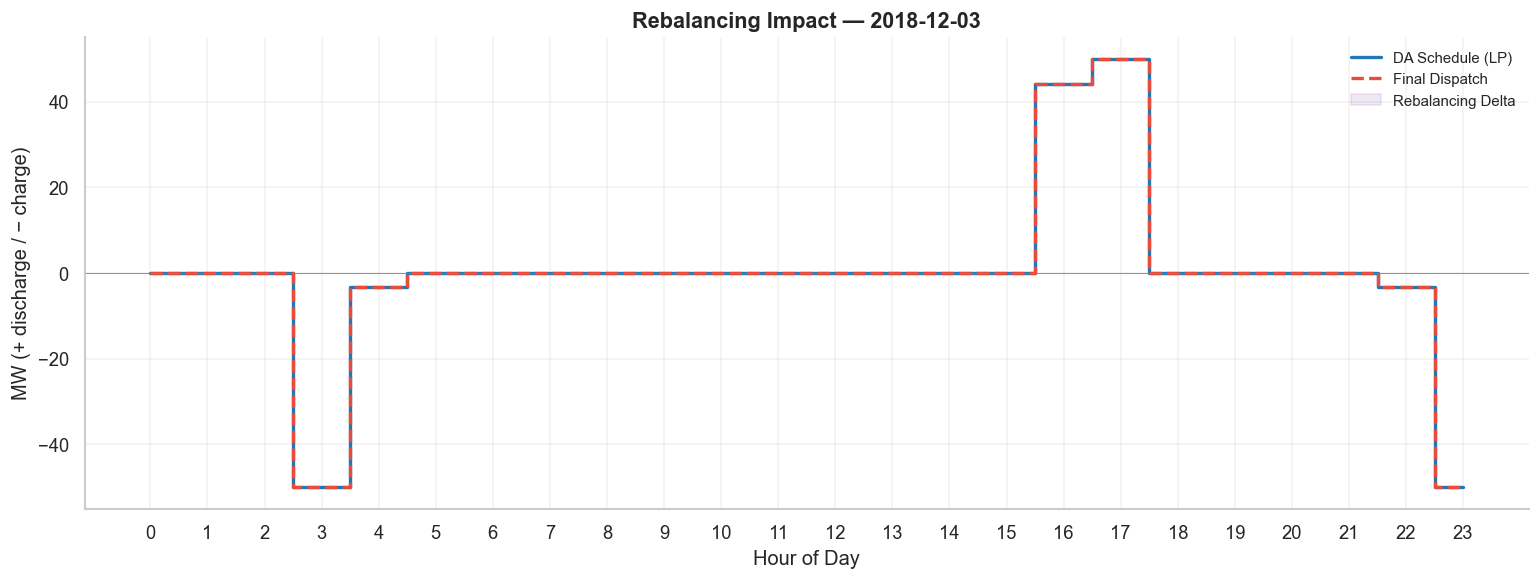

In [18]:
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

actual_mw = []
for _, row in day_dispatch.iterrows():
    if row["action"] == "discharge":
        actual_mw.append(row["mw"])
    elif row["action"] == "charge":
        actual_mw.append(-row["mw"])
    else:
        actual_mw.append(0.0)
actual_mw = np.array(actual_mw)

fig, ax = plt.subplots(figsize=(13, 5))

ax.step(hours, da_mw, where="mid", linewidth=2, color="#1f77b4", label="DA Schedule (LP)")
ax.step(hours, actual_mw, where="mid", linewidth=2, color="#e74c3c", linestyle="--", label="Final Dispatch")

ax.fill_between(hours, da_mw, actual_mw, alpha=0.15, color="#9467bd", step="mid", label="Rebalancing Delta")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MW (+ discharge / − charge)")
ax.set_title(f"Rebalancing Impact — {sample_date}", fontsize=13, fontweight="bold")
ax.set_xticks(hours)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. PnL Waterfall

Stacked decomposition of total net PnL into its four components:

- **DA Revenue** — revenue from committed Day-Ahead positions
- **Intraday PnL** — gains/losses from rebalancing trades at MID
- **Imbalance PnL** — settlement costs/credits for undelivered volume
- **Degradation Cost** — throughput-based battery wear cost (subtracted)

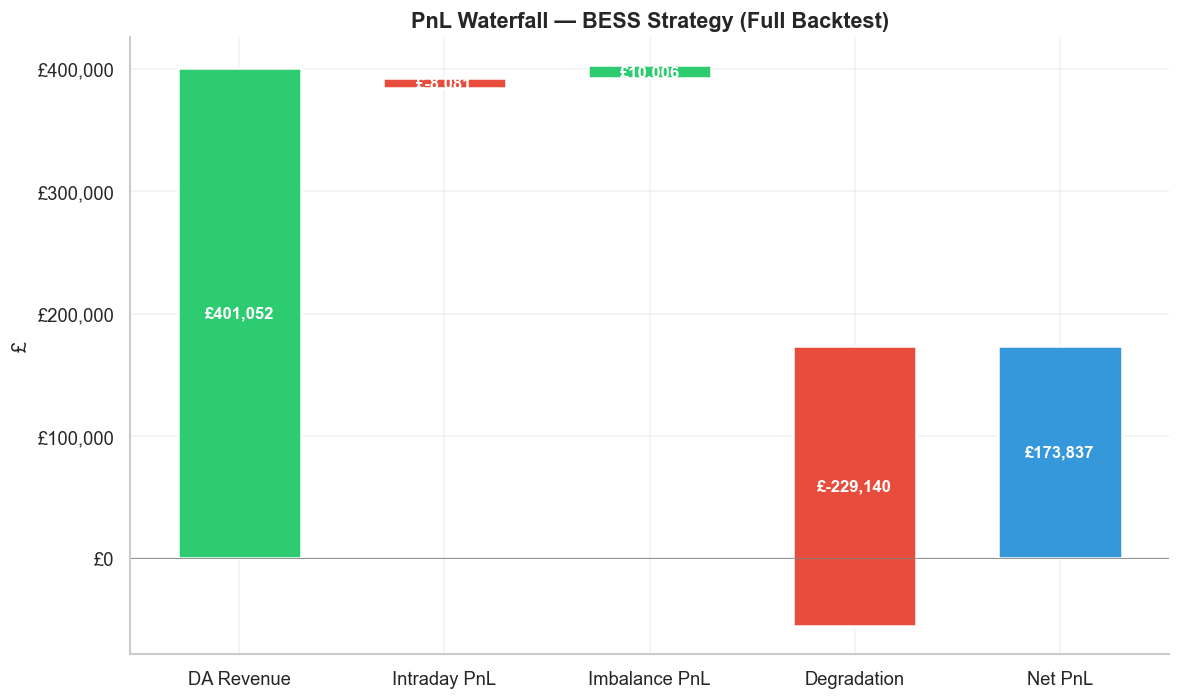

In [19]:
components = {
    "DA Revenue": results_df["da_revenue"].sum(),
    "Intraday PnL": results_df["intraday_pnl"].sum(),
    "Imbalance PnL": results_df["imbalance_pnl"].sum(),
    "Degradation": -results_df["degradation_cost"].sum(),
}
net = sum(components.values())

labels = list(components.keys()) + ["Net PnL"]
values = list(components.values()) + [net]

bottoms = []
running = 0.0
for v in list(components.values()):
    if v >= 0:
        bottoms.append(running)
        running += v
    else:
        running += v
        bottoms.append(running)
bottoms.append(0.0)

colors = []
for v in list(components.values()):
    colors.append("#2ecc71" if v >= 0 else "#e74c3c")
colors.append("#3498db")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, bottom=bottoms, color=colors, width=0.6, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width() / 2, y, f"£{val:,.0f}",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_ylabel("£")
ax.set_title("PnL Waterfall — BESS Strategy (Full Backtest)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 5. Performance Summary

Key risk-return metrics for the BESS strategy over the full backtest period.

In [ ]:
avg_daily = results_df["net_pnl"].mean()
std_daily = results_df["net_pnl"].std(ddof=1)
sharpe = (avg_daily / std_daily) * np.sqrt(365) if std_daily > 0 else 0.0
cumulative = results_df["net_pnl"].cumsum()
max_dd = (cumulative - cumulative.cummax()).min()
total_deg = results_df["degradation_cost"].sum()

summary = pd.DataFrame([
    {"Metric": "Net PnL",               "Value": f"£{results_df['net_pnl'].sum():,.0f}"},
    {"Metric": "Sharpe Ratio (ann.)",    "Value": f"{sharpe:.2f}"},
    {"Metric": "Max Drawdown",           "Value": f"£{max_dd:,.0f}"},
    {"Metric": "Total Degradation Cost", "Value": f"£{total_deg:,.0f}"},
    {"Metric": "Mean Daily PnL",         "Value": f"£{avg_daily:,.0f}"},
    {"Metric": "Days Traded",            "Value": f"{len(results_df)}"},
]).set_index("Metric")

summary.style.set_properties(**{"text-align": "right"})

---
## 6. Revenue Decomposition

Component-level breakdown of total net PnL. Each row maps directly to a column in `results_df`:

| Component | Source Column |
|---|---|
| Day-Ahead Revenue | `da_revenue` |
| Intraday / Rebalancing PnL | `intraday_pnl` |
| Imbalance Costs | `imbalance_pnl` |
| Degradation Costs | `degradation_cost` (sign-flipped) |

In [ ]:
decomp = pd.DataFrame([
    {"Component": "Day-Ahead Revenue",          "Amount": results_df["da_revenue"].sum()},
    {"Component": "Intraday / Rebalancing PnL", "Amount": results_df["intraday_pnl"].sum()},
    {"Component": "Imbalance Costs",            "Amount": results_df["imbalance_pnl"].sum()},
    {"Component": "Degradation Costs",          "Amount": -results_df["degradation_cost"].sum()},
]).set_index("Component")

net_pnl = decomp["Amount"].sum()
decomp["Share (%)"] = decomp["Amount"] / decomp["Amount"].abs().sum() * 100

display(
    decomp.style
    .format({"Amount": "£{:,.0f}", "Share (%)": "{:.1f}%"})
    .set_properties(**{"text-align": "right"})
)

# ── Bar chart ─────────────────────────────────────────────────────────────────
plot_df = pd.concat([decomp, pd.DataFrame({"Amount": [net_pnl], "Share (%)": [100.0]},
                     index=pd.Index(["Net PnL"], name="Component"))])

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in plot_df["Amount"].iloc[:-1]]
bar_colors.append("#3498db")
bars = ax.bar(range(len(plot_df)), plot_df["Amount"], color=bar_colors, width=0.55,
              edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, plot_df["Amount"]):
    y_off = abs(plot_df["Amount"].max()) * 0.04
    y_pos = val + (y_off if val >= 0 else -y_off)
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f"£{val:,.0f}",
            ha="center", va="bottom" if val >= 0 else "top", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.set_ylabel("£")
ax.set_title("Revenue Decomposition — BESS Strategy", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 7. Dispatch Efficiency

Compares the DA-committed MW schedule with the actual dispatched MW for every period in the backtest. The scatter plot shows how closely the intraday engine follows the LP plan; points on the diagonal indicate perfect execution. The metrics table reports mean absolute deviation and the share of periods where actual dispatch matched the commitment within ±5% of rated power.

In [ ]:
efficiency = da_sched_df.merge(
    dispatch_df[["date", "hour", "action", "mw"]],
    on=["date", "hour"],
    how="inner",
)
efficiency["actual_mw"] = np.where(
    efficiency["action"] == "discharge", efficiency["mw"],
    np.where(efficiency["action"] == "charge", -efficiency["mw"], 0.0),
)
efficiency["deviation"] = efficiency["actual_mw"] - efficiency["da_mw"]

mad = efficiency["deviation"].abs().mean()
power_mw = BESS_CFG["power_mw"]
within_5 = (efficiency["deviation"].abs() <= 0.05 * power_mw).mean() * 100

metrics = pd.DataFrame([
    {"Metric": "Mean Absolute Deviation",               "Value": f"{mad:.3f} MW"},
    {"Metric": f"Periods within ±5% of {power_mw} MW",  "Value": f"{within_5:.1f}%"},
    {"Metric": "Total periods evaluated",                "Value": f"{len(efficiency):,}"},
]).set_index("Metric")
display(metrics.style.set_properties(**{"text-align": "right"}))

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(efficiency["da_mw"], efficiency["actual_mw"],
           alpha=0.25, s=12, color="#1f77b4", edgecolors="none")
lims = [
    min(efficiency["da_mw"].min(), efficiency["actual_mw"].min()) - 0.5,
    max(efficiency["da_mw"].max(), efficiency["actual_mw"].max()) + 0.5,
]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect match")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("DA-Committed MW")
ax.set_ylabel("Actual Dispatched MW")
ax.set_title("Dispatch Efficiency — Committed vs. Actual", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## 8. Degradation vs. Revenue

Cumulative gross revenue (DA + intraday + imbalance) alongside cumulative degradation cost by month. The growing gap between the two bars shows the **net benefit of cycles** — how much value the battery extracts after accounting for wear.

In [ ]:
monthly = results_df.copy()
monthly["month"] = monthly["date"].dt.to_period("M")
monthly = monthly.groupby("month").agg(
    da_revenue=("da_revenue", "sum"),
    intraday_pnl=("intraday_pnl", "sum"),
    imbalance_pnl=("imbalance_pnl", "sum"),
    degradation_cost=("degradation_cost", "sum"),
).reset_index()
monthly["gross_revenue"] = monthly["da_revenue"] + monthly["intraday_pnl"] + monthly["imbalance_pnl"]
monthly["cum_revenue"] = monthly["gross_revenue"].cumsum()
monthly["cum_degradation"] = monthly["degradation_cost"].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(monthly))
w = 0.35
ax.bar(x - w / 2, monthly["cum_revenue"], w, label="Cumulative Gross Revenue", color="#2ecc71")
ax.bar(x + w / 2, monthly["cum_degradation"], w, label="Cumulative Degradation Cost", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(monthly["month"].astype(str), rotation=45, ha="right")
ax.set_ylabel("£")
ax.set_title("Cumulative Revenue vs. Degradation Cost by Month", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

net_benefit = monthly["cum_revenue"].iloc[-1] - monthly["cum_degradation"].iloc[-1]
print(f"Net benefit of cycles: £{net_benefit:,.0f}")